In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os, zipfile
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#F8F8F6",
    "axes.grid":        True,
    "grid.color":       "white",
    "grid.linewidth":   1.2,
    "font.family":      "DejaVu Sans",
    "axes.spines.top":  False,
    "axes.spines.right":False,
})

PALETTE     = ["#5C6BC0", "#26A69A", "#EF5350"]
SAVE_DIR    = "/content/iris_plots"
os.makedirs(SAVE_DIR, exist_ok=True)

print("✅ Libraries imported!")
print(f"📁 Plots will be saved to: {SAVE_DIR}")


✅ Libraries imported!
📁 Plots will be saved to: /content/iris_plots


In [2]:
# ── Load from Kaggle/Colab path ───────────────────────────────
DATASET_PATH = "/kaggle/input/iriscsv/Iris.csv"

# Auto-detect file in case of slight name variation
import glob
candidates = glob.glob("/kaggle/input/iriscsv/*.csv")
if candidates:
    DATASET_PATH = candidates[0]
    print(f"📄 Found dataset: {DATASET_PATH}")
else:
    print("⚠️  Kaggle path not found. Falling back to sklearn built-in.")

try:
    df_raw = pd.read_csv(DATASET_PATH)
    print(f"✅ Loaded from CSV: {df_raw.shape}")
except Exception:
    from sklearn.datasets import load_iris as _load
    _iris = _load()
    df_raw = pd.DataFrame(_iris.data, columns=["SepalLengthCm","SepalWidthCm","PetalLengthCm","PetalWidthCm"])
    df_raw["Species"] = [_iris.target_names[t] for t in _iris.target]
    print("✅ Loaded from sklearn built-in (fallback)")

df_raw.head()


⚠️  Kaggle path not found. Falling back to sklearn built-in.
✅ Loaded from sklearn built-in (fallback)


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# ── Standardise column names ──────────────────────────────────
df = df_raw.copy()

# Drop Id column if present
if "Id" in df.columns:
    df.drop(columns="Id", inplace=True)

# Rename to short feature names
rename_map = {
    "SepalLengthCm": "sepal length (cm)",
    "SepalWidthCm":  "sepal width (cm)",
    "PetalLengthCm": "petal length (cm)",
    "PetalWidthCm":  "petal width (cm)",
    "Species":       "species",
}
df.rename(columns={k:v for k,v in rename_map.items() if k in df.columns}, inplace=True)

# Strip "Iris-" prefix if present  (e.g. "Iris-setosa" → "setosa")
df["species"] = df["species"].str.replace("Iris-", "", regex=False).str.lower()
df["species"] = pd.Categorical(df["species"])

FEATURE_COLS  = [c for c in df.columns if c != "species"]
CLASS_NAMES   = list(df["species"].cat.categories)

print("=" * 55)
print("  IRIS FLOWER CLASSIFICATION — CodeAlpha Task 1")
print("=" * 55)
print(f"\n  Shape         : {df.shape}")
print(f"  Features      : {FEATURE_COLS}")
print(f"  Classes       : {CLASS_NAMES}")
print(f"  Samples/class : {df['species'].value_counts().to_dict()}")
print(f"  Missing values: {df.isnull().sum().sum()}")
print()
display(df.describe().round(2))


  IRIS FLOWER CLASSIFICATION — CodeAlpha Task 1

  Shape         : (150, 5)
  Features      : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
  Classes       : ['setosa', 'versicolor', 'virginica']
  Samples/class : {'setosa': 50, 'versicolor': 50, 'virginica': 50}
  Missing values: 0



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


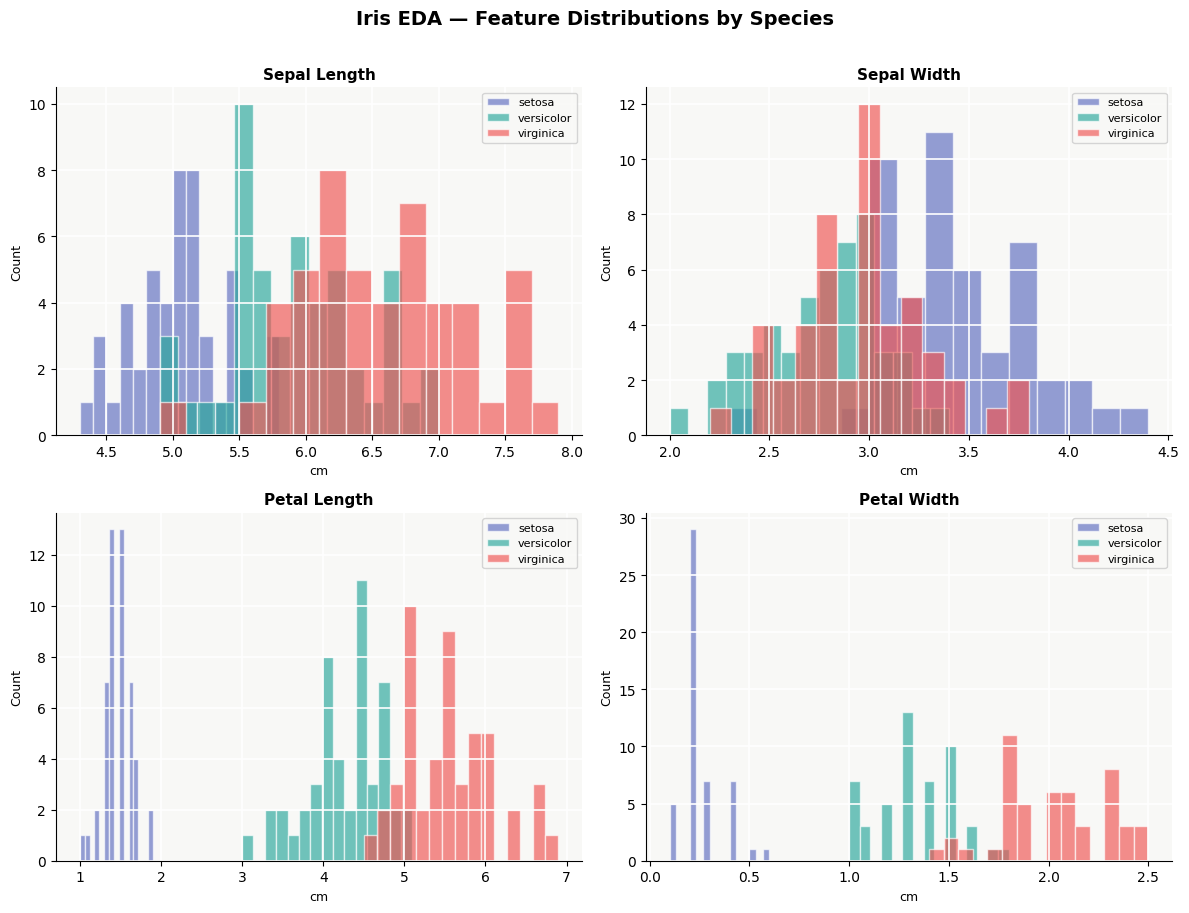

✅ Saved → /content/iris_plots/fig1_distributions.png


In [4]:
fig1, axes = plt.subplots(2, 2, figsize=(12, 9))
fig1.suptitle("Iris EDA — Feature Distributions by Species",
              fontsize=14, fontweight="bold", y=1.01)

for ax, feat in zip(axes.flat, FEATURE_COLS):
    for sp, col in zip(CLASS_NAMES, PALETTE):
        vals = df.loc[df["species"] == sp, feat]
        ax.hist(vals, bins=15, alpha=0.65, color=col, label=sp, edgecolor="white")
    ax.set_title(feat.replace(" (cm)", "").title(), fontsize=11, fontweight="bold")
    ax.set_xlabel("cm", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.legend(fontsize=8)

fig1.tight_layout()
SAVE1 = f"{SAVE_DIR}/fig1_distributions.png"
fig1.savefig(SAVE1, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved → {SAVE1}")


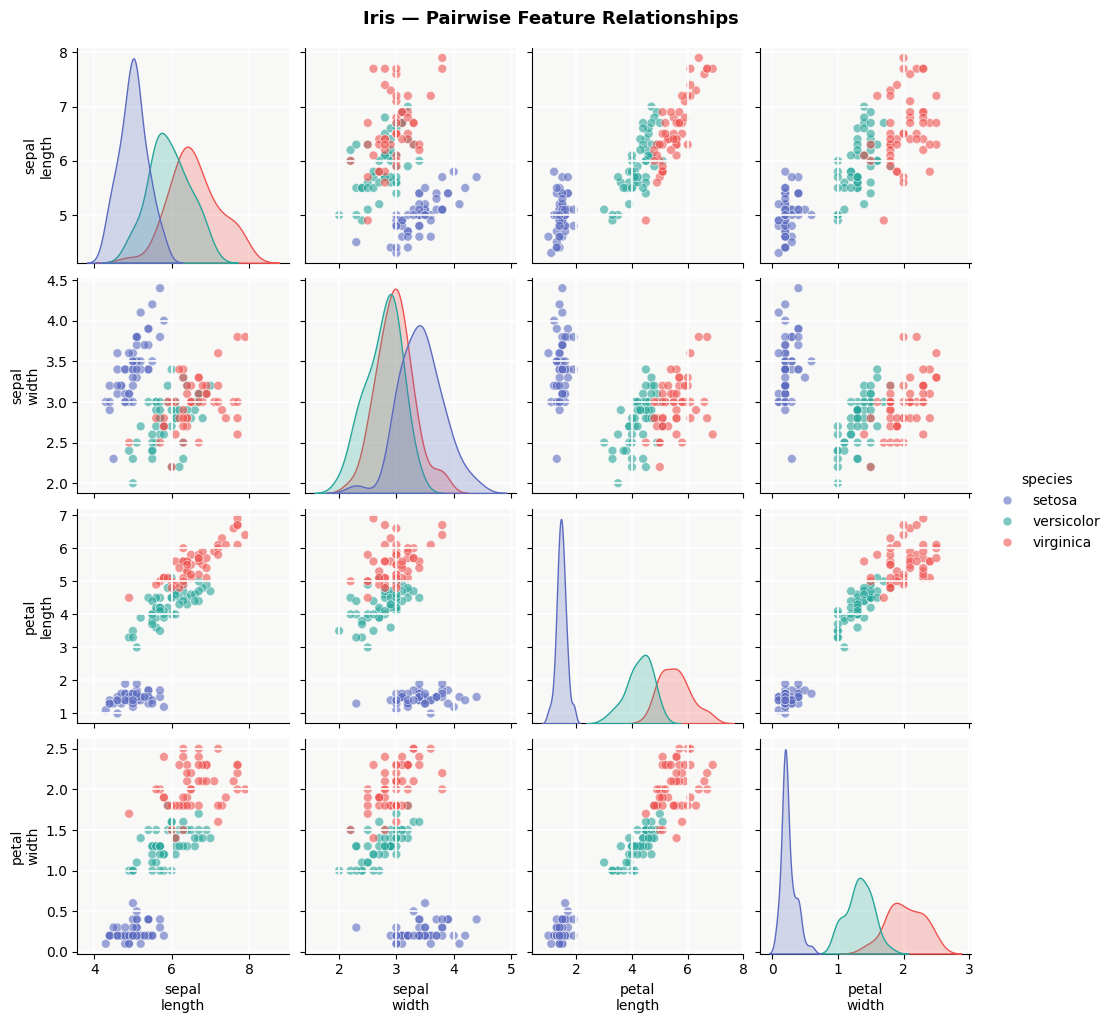

✅ Saved → /content/iris_plots/fig2_pairplot.png


In [5]:
pair_df = df.rename(columns={c: c.replace(" (cm)", "").replace(" ", "\n")
                              for c in df.columns})
pp = sns.pairplot(pair_df, hue="species",
                  palette=dict(zip(CLASS_NAMES, PALETTE)),
                  diag_kind="kde", plot_kws={"alpha": 0.6, "s": 40})
pp.figure.suptitle("Iris — Pairwise Feature Relationships",
                   fontsize=13, fontweight="bold", y=1.02)

SAVE2 = f"{SAVE_DIR}/fig2_pairplot.png"
pp.figure.savefig(SAVE2, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved → {SAVE2}")


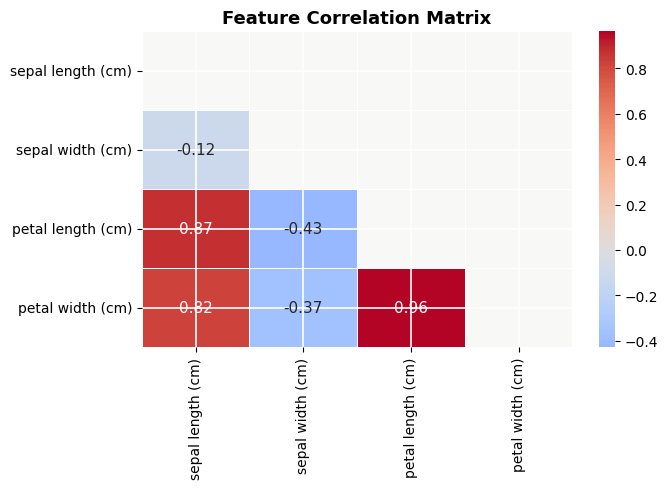

✅ Saved → /content/iris_plots/fig3_correlation.png


In [6]:
fig3, ax3 = plt.subplots(figsize=(7, 5))
corr = df[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0,
            linewidths=0.5, ax=ax3,
            annot_kws={"size": 11})
ax3.set_title("Feature Correlation Matrix", fontsize=13, fontweight="bold")
fig3.tight_layout()

SAVE3 = f"{SAVE_DIR}/fig3_correlation.png"
fig3.savefig(SAVE3, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved → {SAVE3}")


In [7]:
X = df[FEATURE_COLS].values
le = LabelEncoder()
y  = le.fit_transform(df["species"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"✅ Preprocessing done!")
print(f"   Train : {len(X_train)} samples")
print(f"   Test  : {len(X_test)} samples")
print(f"   Classes: {list(le.classes_)}")


✅ Preprocessing done!
   Train : 120 samples
   Test  : 30 samples
   Classes: ['setosa', 'versicolor', 'virginica']


In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (RBF)":           SVC(kernel="rbf", probability=True, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
}

results = {}
print(f"{'Model':<25} {'Test Acc':>10} {'CV Acc (5-fold)':>16}")
print("-" * 55)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred   = model.predict(X_test)
    acc      = accuracy_score(y_test, y_pred)
    cv_score = cross_val_score(model, X_train, y_train, cv=5).mean()
    results[name] = {"accuracy": acc, "cv_score": cv_score,
                     "model": model, "y_pred": y_pred}
    star = "★" if acc == max(r["accuracy"] for r in results.values()) else " "
    print(f"  {star} {name:<23} {acc*100:>9.1f}%  {cv_score*100:>14.1f}%")

best_name  = max(results, key=lambda k: results[k]["accuracy"])
best_model = results[best_name]["model"]
y_pred_best = results[best_name]["y_pred"]

print(f"\n  ★ Best model: {best_name} ({results[best_name]['accuracy']*100:.1f}%)")


Model                       Test Acc  CV Acc (5-fold)
-------------------------------------------------------
  ★ Logistic Regression          93.3%            95.8%
  ★ Decision Tree                93.3%            94.2%
    Random Forest                90.0%            95.0%
  ★ SVM (RBF)                    96.7%            96.7%
    K-Nearest Neighbors          93.3%            96.7%

  ★ Best model: SVM (RBF) (96.7%)


In [9]:
# Detailed classification report for best model
print(f"\nClassification Report — {best_name}")
print("-" * 50)
print(classification_report(y_test, y_pred_best, target_names=le.classes_))



Classification Report — SVM (RBF)
--------------------------------------------------
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



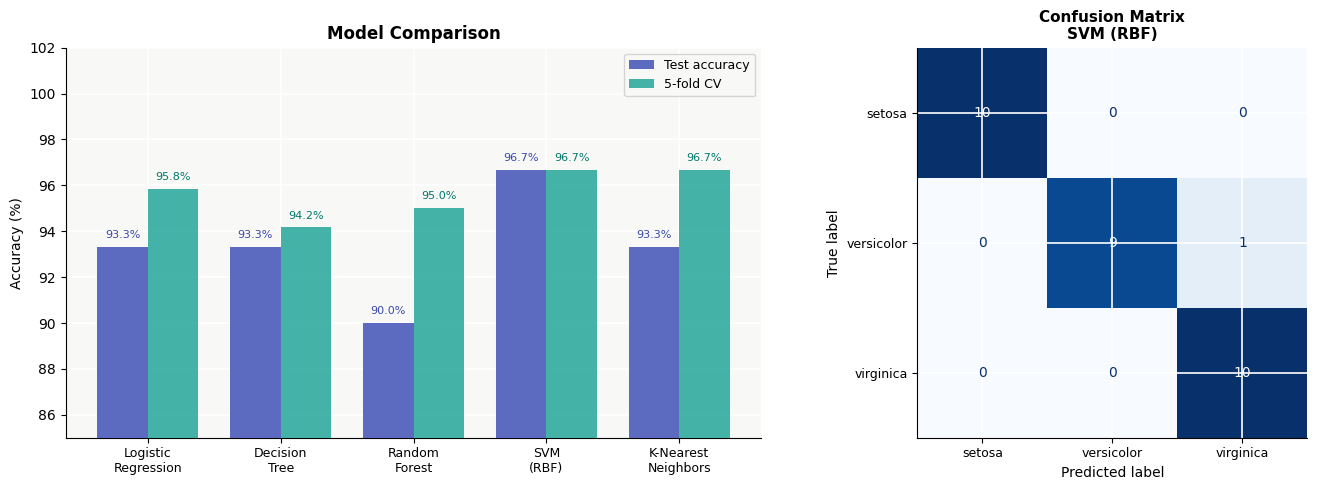

✅ Saved → /content/iris_plots/fig4_model_results.png


In [10]:
fig4 = plt.figure(figsize=(14, 5))
gs   = gridspec.GridSpec(1, 2, width_ratios=[1.3, 1])

# ── Bar chart ────────────────────────────────────────────────
ax_bar = fig4.add_subplot(gs[0])
names  = list(results.keys())
accs   = [results[n]["accuracy"] * 100 for n in names]
cvs    = [results[n]["cv_score"]  * 100 for n in names]
x, w   = np.arange(len(names)), 0.38

bars1 = ax_bar.bar(x - w/2, accs, w, label="Test accuracy",
                   color="#5C6BC0", zorder=3)
bars2 = ax_bar.bar(x + w/2, cvs,  w, label="5-fold CV",
                   color="#26A69A", alpha=0.85, zorder=3)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels([n.replace(" ", "\n") for n in names], fontsize=9)
ax_bar.set_ylim(85, 102)
ax_bar.set_ylabel("Accuracy (%)")
ax_bar.set_title("Model Comparison", fontsize=12, fontweight="bold")
ax_bar.legend(fontsize=9)

for bar in bars1:
    ax_bar.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f"{bar.get_height():.1f}%", ha="center", va="bottom",
                fontsize=8, color="#3949AB")
for bar in bars2:
    ax_bar.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f"{bar.get_height():.1f}%", ha="center", va="bottom",
                fontsize=8, color="#00796B")

# ── Confusion matrix ─────────────────────────────────────────
ax_cm = fig4.add_subplot(gs[1])
cm    = confusion_matrix(y_test, y_pred_best)
disp  = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=ax_cm, colorbar=False, cmap="Blues")
ax_cm.set_title(f"Confusion Matrix\n{best_name}", fontsize=11, fontweight="bold")
ax_cm.tick_params(labelsize=9)

fig4.tight_layout()
SAVE4 = f"{SAVE_DIR}/fig4_model_results.png"
fig4.savefig(SAVE4, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved → {SAVE4}")


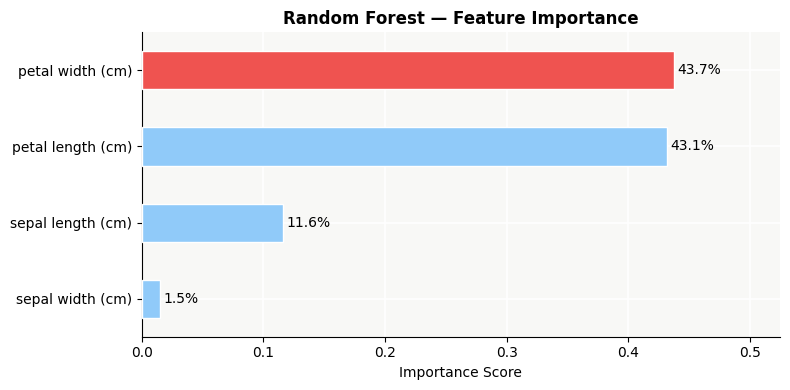

✅ Saved → /content/iris_plots/fig5_feature_importance.png

Feature Importance Ranking:
  petal width (cm)        0.4372  █████████████████████
  petal length (cm)       0.4315  █████████████████████
  sepal length (cm)       0.1163  █████
  sepal width (cm)        0.0150  


In [11]:
rf_model    = results["Random Forest"]["model"]
importances = pd.Series(rf_model.feature_importances_,
                        index=FEATURE_COLS).sort_values(ascending=True)

fig5, ax5 = plt.subplots(figsize=(8, 4))
bar_colors = ["#EF5350" if i == len(importances)-1 else "#90CAF9"
              for i in range(len(importances))]
importances.plot.barh(ax=ax5, color=bar_colors, edgecolor="white", zorder=3)

for i, (val, label) in enumerate(zip(importances.values, importances.index)):
    ax5.text(val + 0.003, i, f"{val*100:.1f}%", va="center", fontsize=10)

ax5.set_title("Random Forest — Feature Importance",
              fontsize=12, fontweight="bold")
ax5.set_xlabel("Importance Score")
ax5.set_xlim(0, importances.max() * 1.2)
fig5.tight_layout()

SAVE5 = f"{SAVE_DIR}/fig5_feature_importance.png"
fig5.savefig(SAVE5, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved → {SAVE5}")

print("\nFeature Importance Ranking:")
for feat, imp in importances.sort_values(ascending=False).items():
    bar = "█" * int(imp * 50)
    print(f"  {feat:<22}  {imp:.4f}  {bar}")
